In [1]:
## libraries to install ##
#!pip install seaborn pandas matplotlib numpy tabulate plotly

import os
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
from matplotlib.gridspec import GridSpec

from hbn.constants import Defaults  
from hbn.visualization import make_tables, visualize as vis
from hbn import io
from hbn.scripts.make_firstlevel_model import make_features
from hbn.scripts import make_specs

import plotly.io as pio
pio.renderers.default='notebook'

%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

In [2]:
vis.plotting_style()

In [4]:
## Functions

def get_features(feature_spec='features-Child-reading-spec.json', 
                 participant_spec='participants-Reading-all-spec.json',
                 target_spec='target-Diagnosis-spec.json',
                 demos='demographics_reading_impairment.csv'
                 ):
    
    # run get specs first 
    make_specs.run()

    # get specs
    feature_spec = os.path.join(Defaults.MODEL_SPECS_DIR, feature_spec)
    target_spec = os.path.join(Defaults.MODEL_SPECS_DIR, target_spec)
    participant_spec = os.path.join(Defaults.MODEL_SPECS_DIR, participant_spec)

    # get features
    df_train, df_test, _, _, df_index =  make_features(feature_info=feature_spec,   
                                                        target_info=target_spec,
                                                        participant_info=participant_spec,
                                                        data_dir=Defaults.INTERIM_FEATURES_DIR,
                                                        drop_identifiers=False
                                                        )
    df_features = pd.concat([df_train, df_test])

    # load demos and merge with features
    df_demos = pd.read_csv(os.path.join(Defaults.PROCESSED_FIG_DIR, demos))
    df_out = df_features.merge(df_demos, on=['Identifiers'])

    return df_out

### Raw Scores - TOWRE and WIAT

created pydraml specs, saved to /net/vast-storage/scratch/vast/gablab/maedbh/healthy_brain_network/model_specs
created participant specs, saved to /net/vast-storage/scratch/vast/gablab/maedbh/healthy_brain_network/model_specs
created feature specs, saved to /net/vast-storage/scratch/vast/gablab/maedbh/healthy_brain_network/model_specs
created target specs, saved to /net/vast-storage/scratch/vast/gablab/maedbh/healthy_brain_network/model_specs
loaded data from /om2/user/maedbh/hbn_data/interim/phenotypes
combined features and targets
filtered participants


<Figure size 1280x880 with 0 Axes>

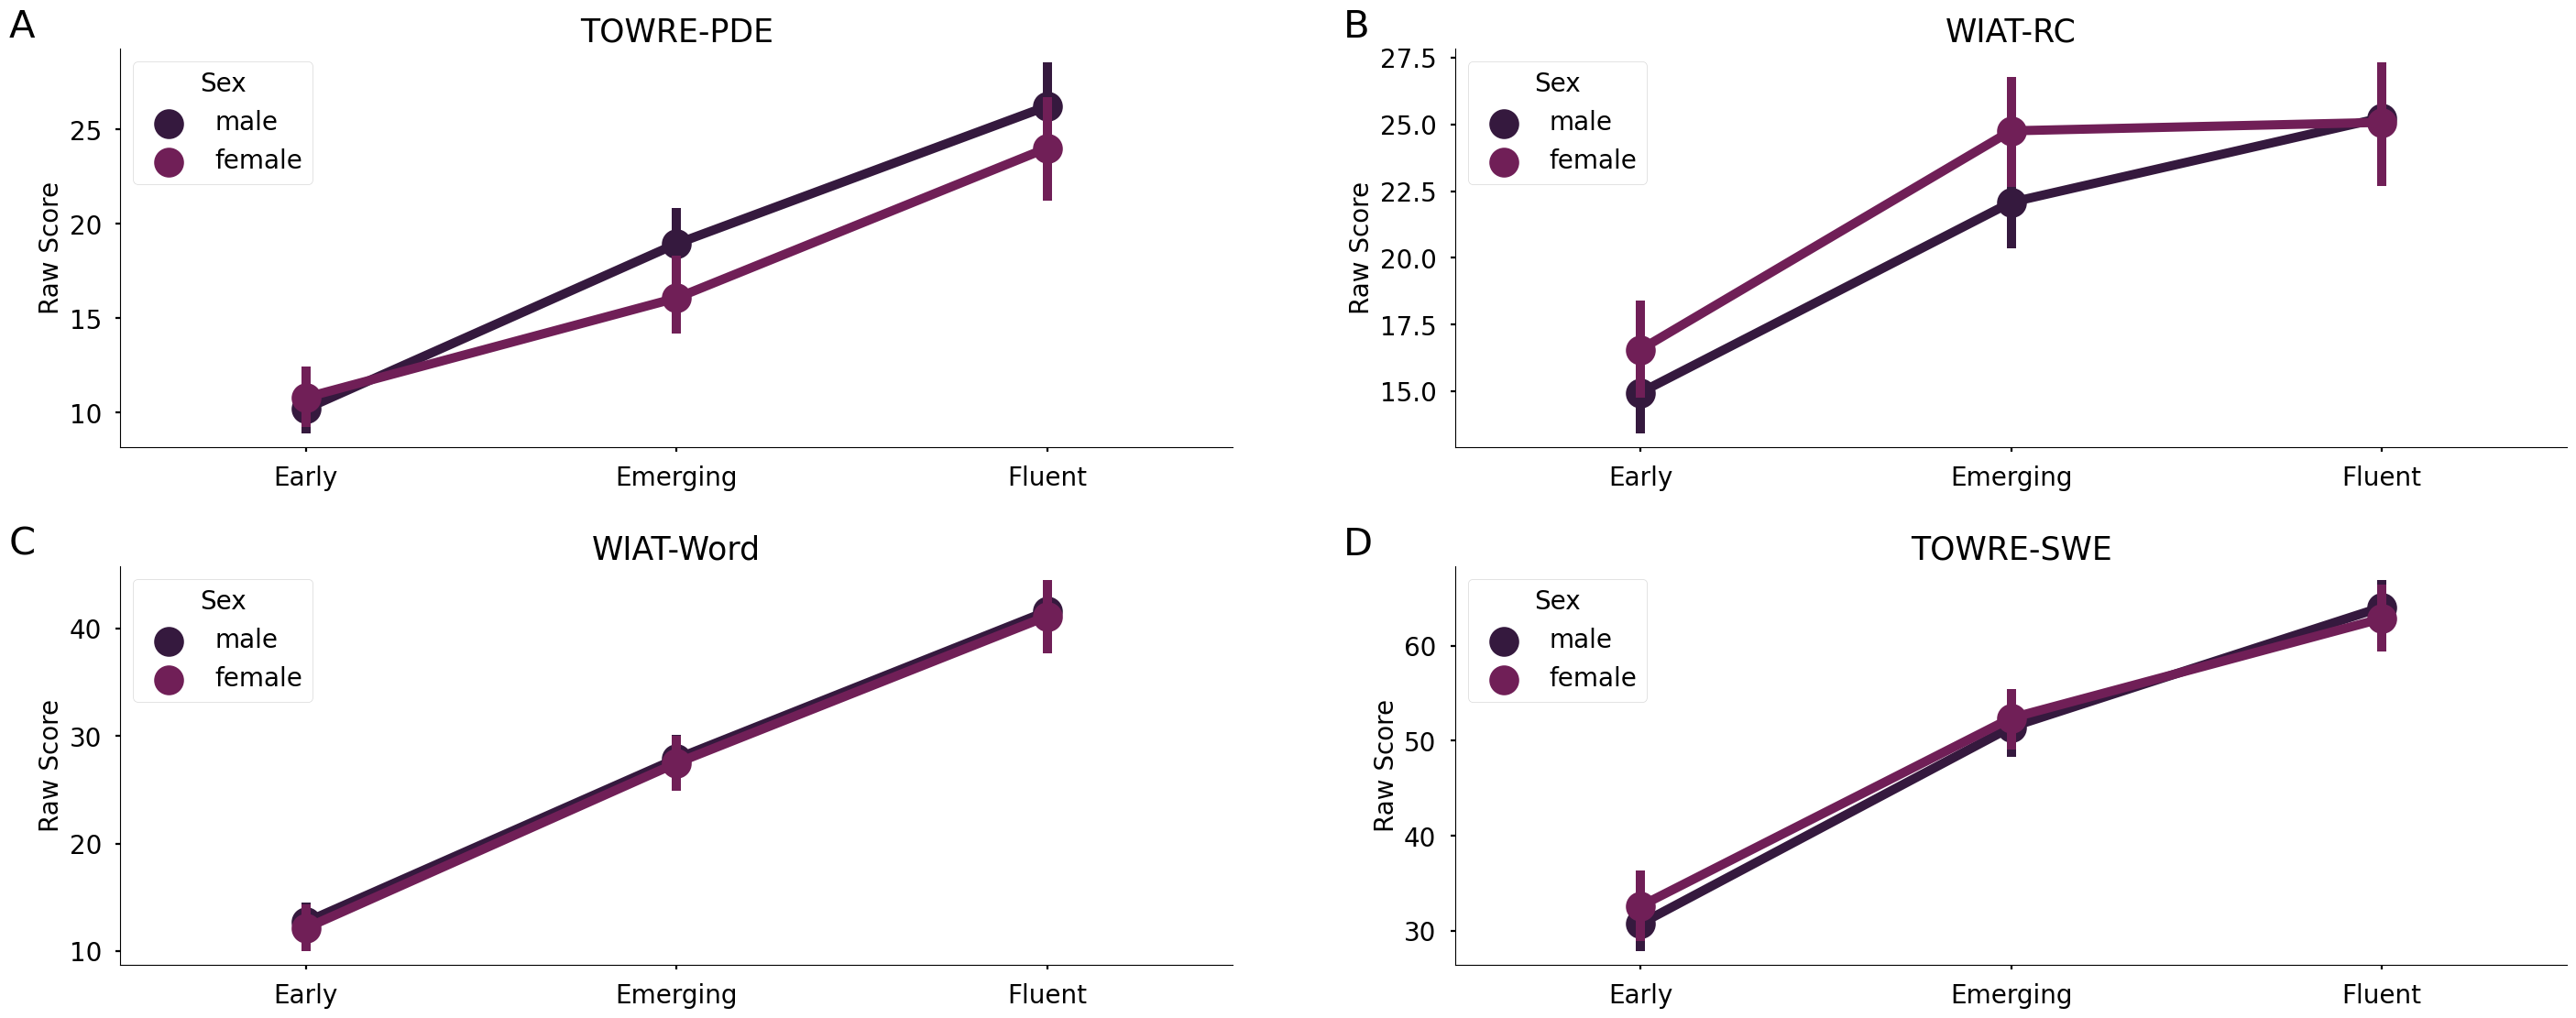

In [6]:
# get features
TOWRE_WIAT = get_features(feature_spec='features-Child-reading-all-scores-spec.json',
                        participant_spec='participants-Reading-all-spec.json')

diagnosis = TOWRE_WIAT[TOWRE_WIAT['Diagnosis']=='Reading Impairment']
no_diagnosis = TOWRE_WIAT[TOWRE_WIAT['Diagnosis']=='No Diagnosis Given']

def plot(ax, y, data=diagnosis, x='development_stage', hue='Sex', order=['Early', 'Emerging', 'Fluent'], title='', subplot=None):
    ax = sns.pointplot(
                x=x, 
                y=y, 
                hue=hue, 
                data=data, 
                order=order,
                ax=ax
                )
    ax.set_xlabel('')
    ax.set_ylabel('Raw Score')
    plt.title(title)
    sns.despine()
    ax.text(x_pos, y_pos, subplot, transform=ax.transAxes, fontsize=labelsize, verticalalignment='top')

    return ax

vis.plotting_style()
x_pos = -0.1
y_pos = 1.1
labelsize = 30
plt.clf()
fig = plt.figure(figsize=(4,5))
gs = GridSpec(2, 2, figure=fig)

# A
ax = fig.add_subplot(gs[0,0])
ax = plot(ax=ax, y='numeric__TOWRE,TOWRE_PDE_Raw', title='TOWRE-PDE', subplot='A')

# B
ax = fig.add_subplot(gs[0,1])
ax = plot(ax=ax, y='numeric__WIAT,WIAT_RC_Raw', title='WIAT-RC', subplot='B')

# C
ax = fig.add_subplot(gs[1,0])
ax = plot(ax=ax, y='numeric__WIAT,WIAT_Word_Raw', title='WIAT-Word', subplot='C')

# D
ax = fig.add_subplot(gs[1,1])
ax = plot(ax=ax, y='numeric__TOWRE,TOWRE_SWE_Raw', title='TOWRE-SWE', subplot='D')

fig.subplots_adjust(left=0.125, bottom=0.001, right=6.8, top=2.0, wspace=.2, hspace=.3)
fig.savefig(os.path.join(Defaults.FIG_DIR, f'raw-scores-readers-ages-male-female-No-Diagnosis.png'), bbox_inches='tight')


<Figure size 1280x880 with 0 Axes>

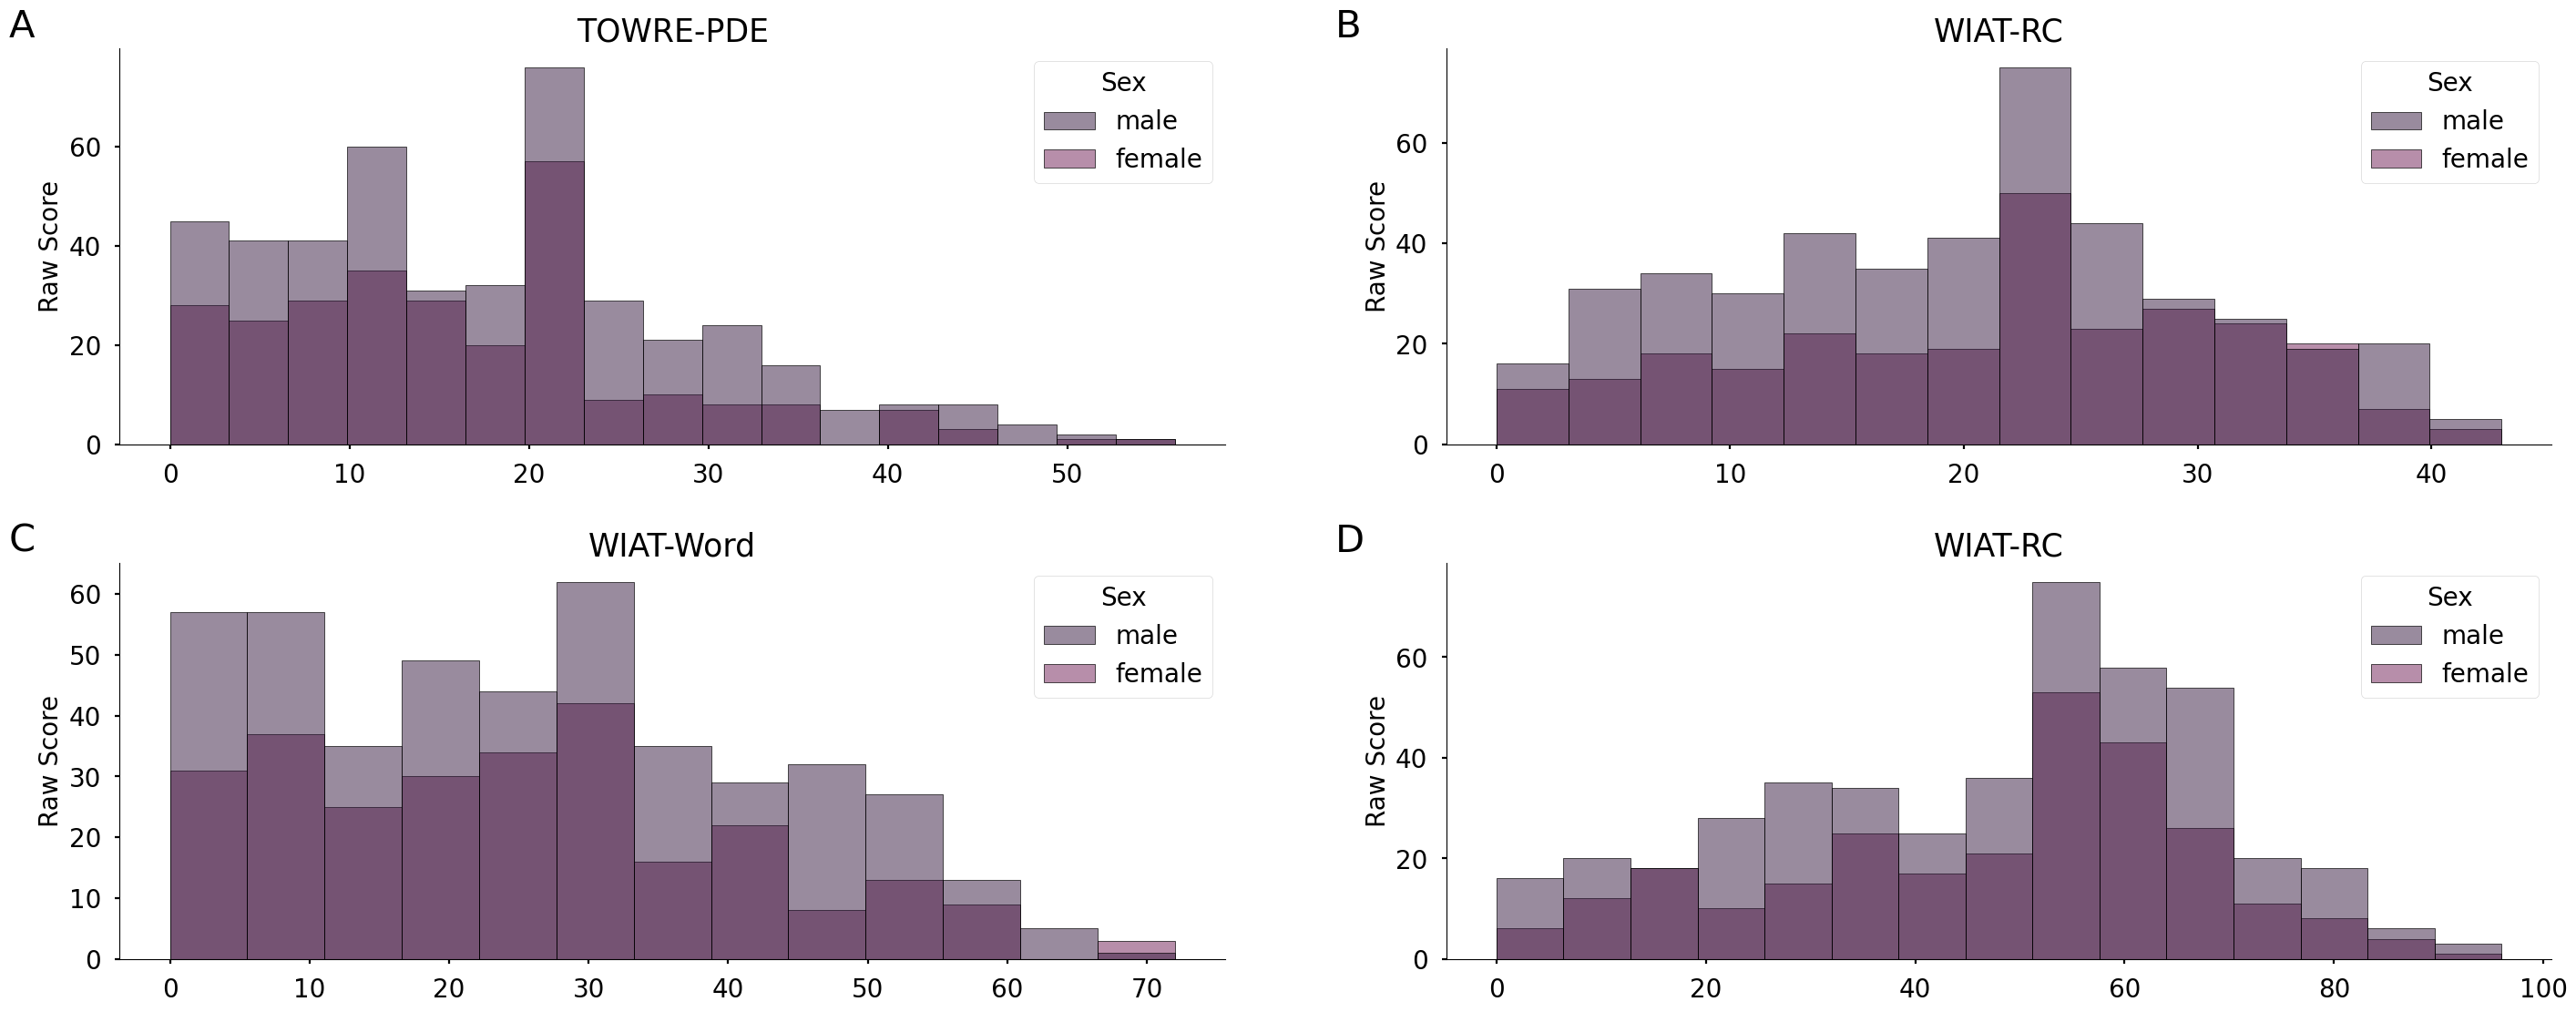

In [7]:
vis.plotting_style()
x_pos = -0.1
y_pos = 1.1
labelsize = 30
plt.clf()
fig = plt.figure(figsize=(4,5))
gs = GridSpec(2, 2, figure=fig)

def histplot(ax, x, data, hue='Sex', title='', subplot=None):
    ax = sns.histplot( 
            x=x, 
            data=diagnosis, 
            hue=hue,
            ax=ax
            )
    ax.set_xlabel('')
    ax.set_ylabel('Raw Score')
    plt.title(title)
    sns.despine()
    ax.text(x_pos, y_pos, subplot, transform=ax.transAxes, fontsize=labelsize, verticalalignment='top')

    return ax

# A
ax = fig.add_subplot(gs[0,0])
ax = histplot(ax, x='numeric__TOWRE,TOWRE_PDE_Raw', data=diagnosis,  title='TOWRE-PDE', subplot='A')

# B
ax = fig.add_subplot(gs[0,1])
ax = histplot(ax, x='numeric__WIAT,WIAT_RC_Raw', data=diagnosis, title='WIAT-RC', subplot='B')

# C
ax = fig.add_subplot(gs[1,0])
ax = histplot(ax, x='numeric__WIAT,WIAT_Word_Raw', data=diagnosis, title='WIAT-Word', subplot='C')

# D
ax = fig.add_subplot(gs[1,1])
ax = histplot(ax, x='numeric__TOWRE,TOWRE_SWE_Raw', data=diagnosis, title='WIAT-RC', subplot='D')

fig.subplots_adjust(left=0.125, bottom=0.001, right=6.8, top=2.0, wspace=.2, hspace=.3)

fig.savefig(os.path.join(Defaults.FIG_DIR, f'raw-scores-readers-ages-male-female-No-agg-scores.png'), bbox_inches='tight')

<Figure size 1280x880 with 0 Axes>

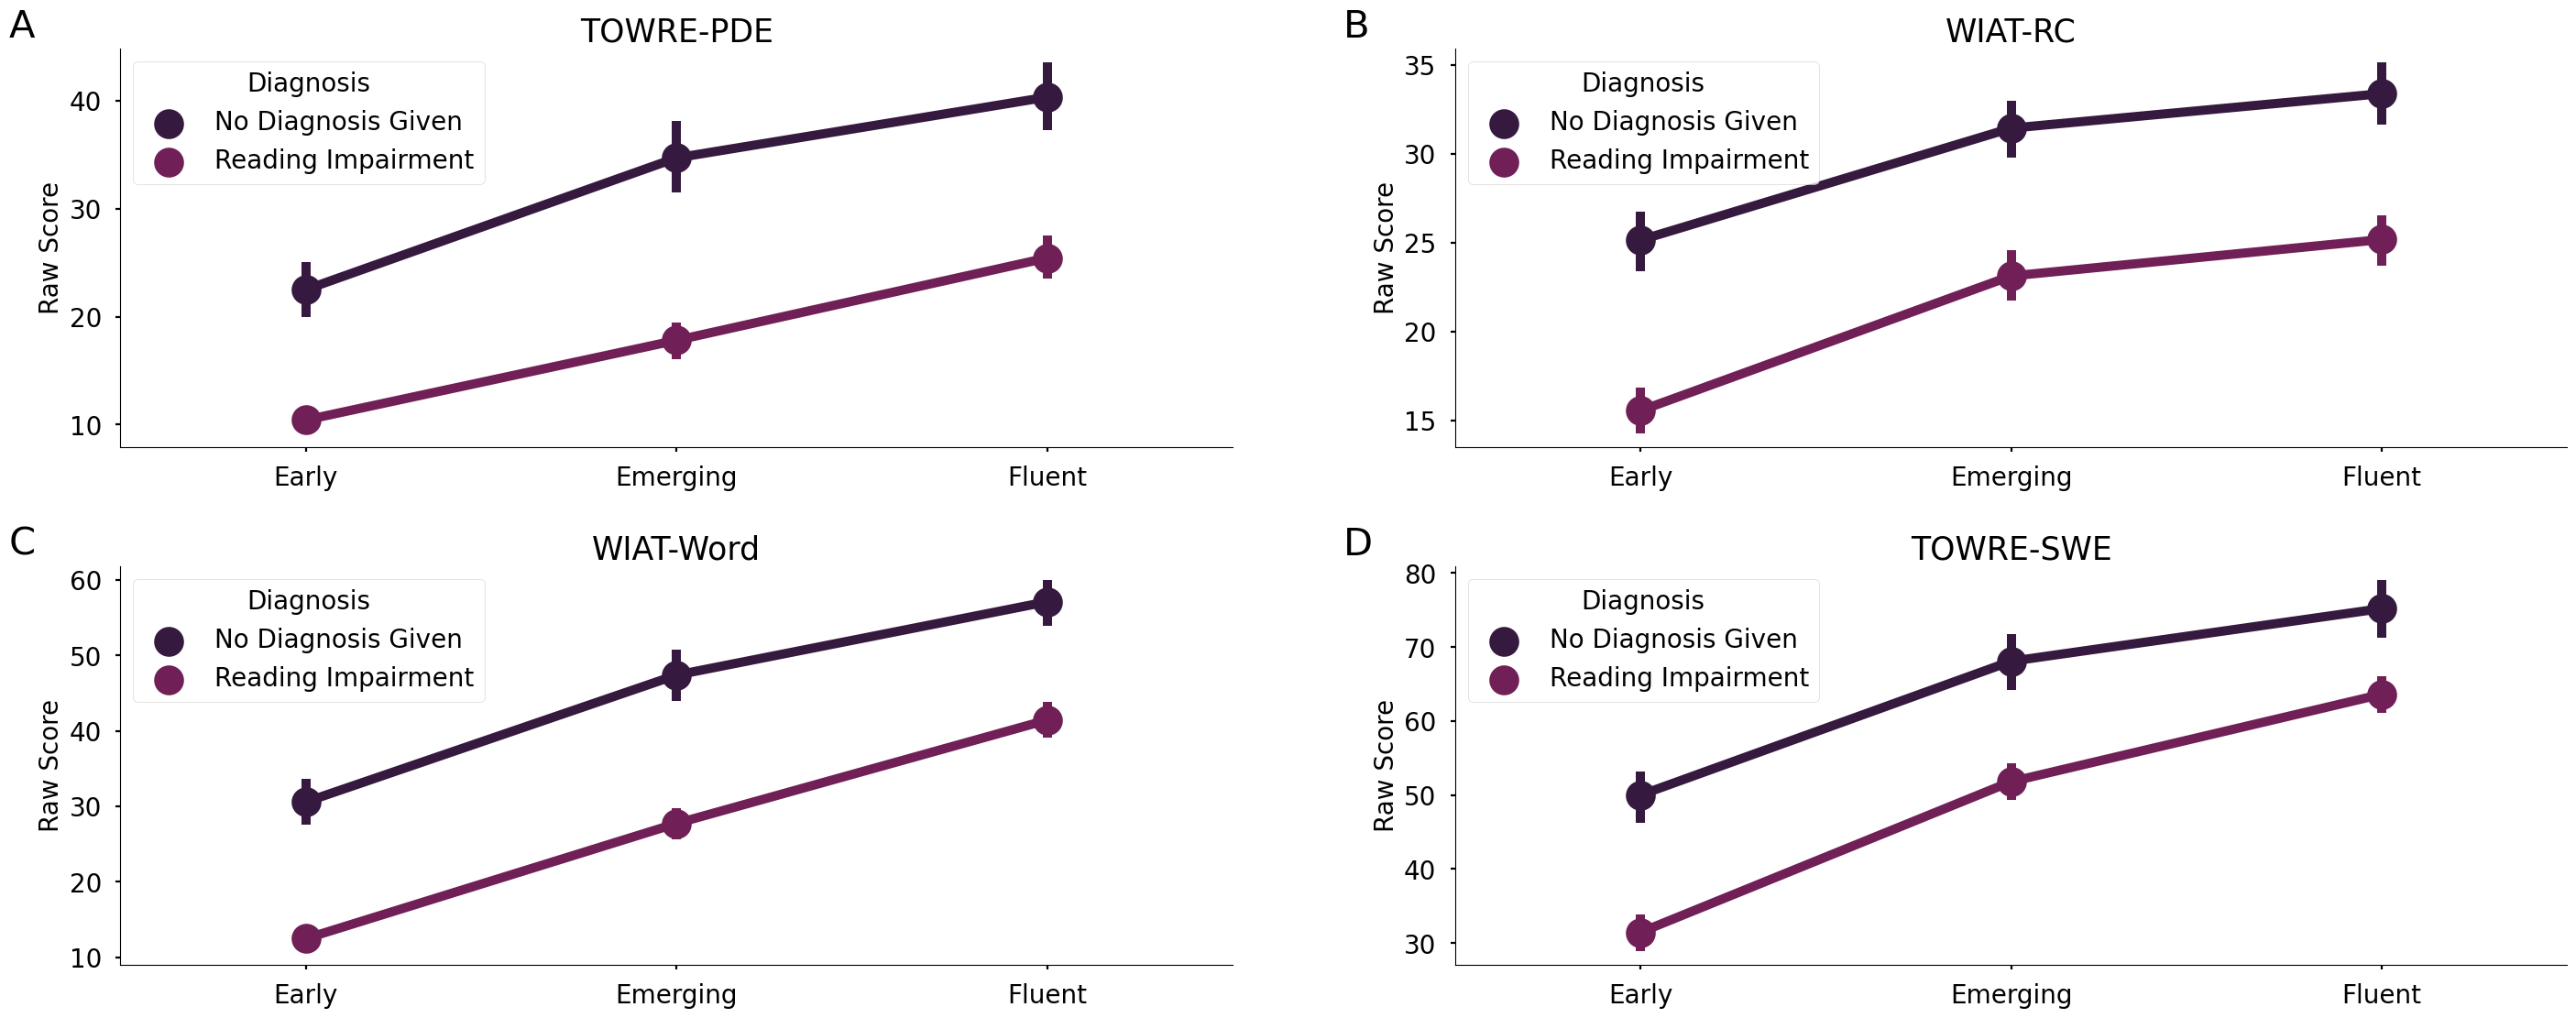

In [8]:
# get features
# TOWRE_WIAT = get_features(feature_spec='features-Child-reading-all-scores-spec.json',
#                         participant_spec='participants-Reading-all-spec.json')

vis.plotting_style()
x_pos = -0.1
y_pos = 1.1
labelsize = 30
plt.clf()
fig = plt.figure(figsize=(4,5))
gs = GridSpec(2, 2, figure=fig)

def plot(ax, y, data=TOWRE_WIAT, x='development_stage', hue='Diagnosis', order=['Early', 'Emerging', 'Fluent'], title='', subplot=None):
    ax = sns.pointplot(
                x=x, 
                y=y, 
                hue=hue, 
                data=data, 
                order=order,
                ax=ax
                )
    ax.set_xlabel('')
    ax.set_ylabel('Raw Score')
    plt.title(title)
    sns.despine()
    ax.text(x_pos, y_pos, subplot, transform=ax.transAxes, fontsize=labelsize, verticalalignment='top')

    return ax

# A
ax = fig.add_subplot(gs[0,0])
ax = plot(ax=ax, y='numeric__TOWRE,TOWRE_PDE_Raw', title='TOWRE-PDE', subplot='A')

# B
ax = fig.add_subplot(gs[0,1])
ax = plot(ax=ax, y='numeric__WIAT,WIAT_RC_Raw', title='WIAT-RC', subplot='B')

# C
ax = fig.add_subplot(gs[1,0])
ax = plot(ax=ax, y='numeric__WIAT,WIAT_Word_Raw', title='WIAT-Word', subplot='C')

# D
ax = fig.add_subplot(gs[1,1])
ax = plot(ax=ax, y='numeric__TOWRE,TOWRE_SWE_Raw', title='TOWRE-SWE', subplot='D')

fig.subplots_adjust(left=0.125, bottom=0.001, right=6.8, top=2.0, wspace=.2, hspace=.3)
fig.savefig(os.path.join(Defaults.FIG_DIR, f'raw-scores-readers-compare-diagnoses.png'), bbox_inches='tight')


In [ ]:
vis.plotting_style()
x_pos = -0.1
y_pos = 1.1
labelsize = 30
plt.clf()
fig = plt.figure(figsize=(4,5))
gs = GridSpec(1, 2, figure=fig)

# A
ax = fig.add_subplot(gs[0,1])
# ax.get_legend().remove()
ax = sns.pointplot(x='development_stage', 
            y='numeric__WIAT,WIAT_LCRV_Raw', 
            hue='Sex', 
            data=diagnosis, 
            order=['Early', 'Emerging', 'Fluent'],
            ax=ax
            )
plt.ylabel('Raw Score')
ax.set_xlabel('')
plt.title('WIAT-Word')
ax.text(x_pos, y_pos, 'A', transform=ax.transAxes, fontsize=labelsize, verticalalignment='top')

# B
ax = fig.add_subplot(gs[0,1])
# ax.get_legend().remove()
ax = sns.pointplot(x='development_stage', 
            y='numeric__WIAT,WIAT_LCODC_Raw', 
            hue='Sex', 
            data=diagnosis, 
            order=['Early', 'Emerging', 'Fluent'],
            ax=ax
            )
plt.ylabel('Raw Score')
ax.set_xlabel('')
plt.title('TOWRE-SWE')
sns.despine()
ax.text(x_pos, y_pos, 'B', transform=ax.transAxes, fontsize=labelsize, verticalalignment='top')

fig.subplots_adjust(left=0.125, bottom=0.001, right=6.8, top=2.0, wspace=.2, hspace=.3)
fig.savefig(os.path.join(Defaults.FIG_DIR, f'raw-scores-readers-language-comprehension-males-females.png'), bbox_inches='tight')

### Raw Scores - Internalizing and Externalizing

In [18]:
# get features
# Int_Ext = get_features(feature_spec='features-all-internalizing-externalizing-spec.json',
#                         participant_spec='participants-Reading-all-spec.json')

Int_Ext.columns = Int_Ext.columns.str.replace('numeric__', '')

Int_Ext_filter = Int_Ext[
                ['Sex', 'development_stage', 'TRF,TRF_Int', 
                'CBCL,CBCL_Int', 'YSR,YSR_Int', 'TRF,TRF_Ext', 
                'CBCL,CBCL_Ext','YSR,YSR_Ext']
                ]

columns_to_melt = ['TRF,TRF_Int', 
                'CBCL,CBCL_Int', 'YSR,YSR_Int', 'TRF,TRF_Ext', 
                'CBCL,CBCL_Ext','YSR,YSR_Ext']

df_reshaped = Int_Ext_filter.melt(id_vars=Int_Ext_filter.columns.difference(columns_to_melt), value_vars=columns_to_melt, ignore_index=True)

df_reshaped['assessment'] = df_reshaped['variable'].str.extract('(TRF|CBCL|YSR)')
df_reshaped['Int_Ext'] = df_reshaped['variable'].str.extract('(Int|Ext)')


<Figure size 1280x880 with 0 Axes>

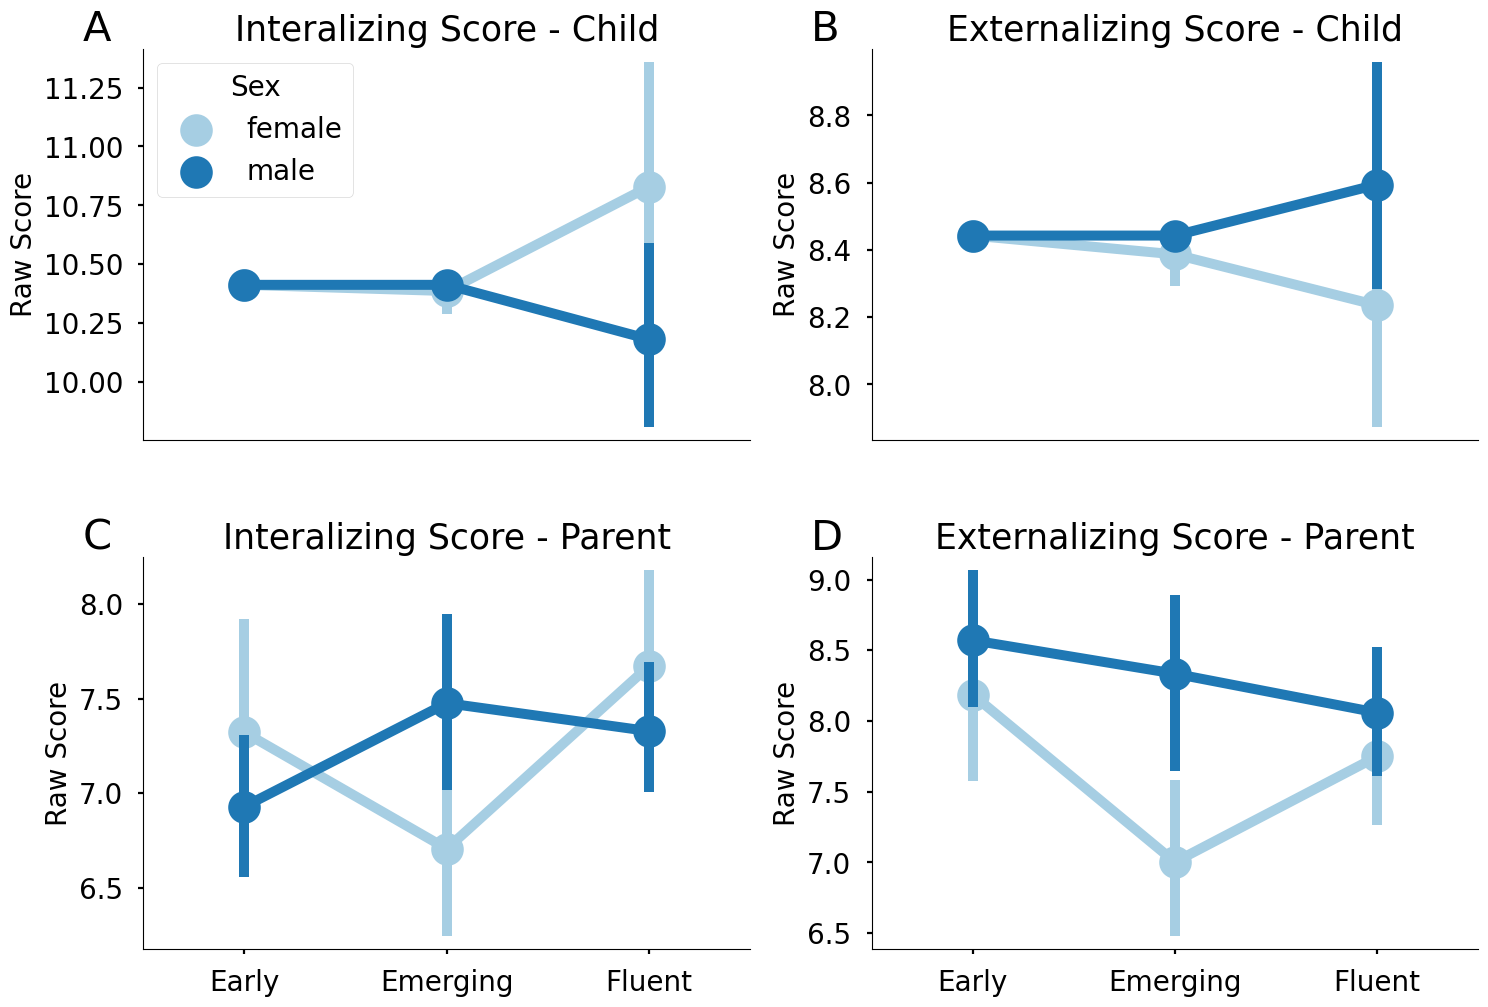

In [37]:
vis.plotting_style()
x_pos = -0.1
y_pos = 1.1
labelsize = 30
plt.clf()
fig = plt.figure(figsize=(2,3))
gs = GridSpec(2, 2, figure=fig)

Child_Int = df_reshaped[(df_reshaped['Int_Ext']=="Int") & (df_reshaped['assessment']=='YSR')]
Child_Ext = df_reshaped[(df_reshaped['Int_Ext']=="Ext") & (df_reshaped['assessment']=='YSR')]
Parent_Int = df_reshaped[(df_reshaped['Int_Ext']=="Int") & (df_reshaped['assessment']=='CBCL')]
Parent_Ext = df_reshaped[(df_reshaped['Int_Ext']=="Ext") & (df_reshaped['assessment']=='CBCL')]
Teacher_Int = df_reshaped[(df_reshaped['Int_Ext']=="Int") & (df_reshaped['assessment']=='TRF')]
Teacher_Ext = df_reshaped[(df_reshaped['Int_Ext']=="Ext") & (df_reshaped['assessment']=='TRF')]

# A
ax = fig.add_subplot(gs[0,0])
ax = sns.pointplot(x='development_stage', 
            y='value', 
            hue='Sex', 
            data=Child_Int, 
            order=['Early', 'Emerging', 'Fluent'],
            ax=ax
            )
plt.ylabel('Raw Score')
plt.xlabel('')
ax.xaxis.set_visible(False)
plt.title('Interalizing Score - Child')
ax.text(x_pos, y_pos, 'A', transform=ax.transAxes, fontsize=labelsize, verticalalignment='top')

# B
ax = fig.add_subplot(gs[0,1])
ax = sns.pointplot(x='development_stage', 
            y='value', 
            hue='Sex', 
            data=Child_Ext, 
            order=['Early', 'Emerging', 'Fluent'],
            ax=ax
            )
ax.get_legend().remove()
plt.ylabel('Raw Score')
ax.xaxis.set_visible(False)
plt.xlabel('')
plt.title('Externalizing Score - Child')
ax.text(x_pos, y_pos, 'B', transform=ax.transAxes, fontsize=labelsize, verticalalignment='top')

# C
ax = fig.add_subplot(gs[1,0])
ax = sns.pointplot(x='development_stage', 
            y='value', 
            hue='Sex', 
            data=Parent_Int, 
            order=['Early', 'Emerging', 'Fluent'],
            ax=ax
            )
ax.get_legend().remove()
plt.ylabel('Raw Score')
plt.title('Interalizing Score - Parent')
plt.xlabel('')
ax.text(x_pos, y_pos, 'C', transform=ax.transAxes, fontsize=labelsize, verticalalignment='top')

# D
ax = fig.add_subplot(gs[1,1])
ax = sns.pointplot(x='development_stage', 
            y='value', 
            hue='Sex', 
            data=Parent_Ext, 
            order=['Early', 'Emerging', 'Fluent'],
            ax=ax
            )
ax.get_legend().remove()
plt.ylabel('Raw Score')
plt.xlabel('')
plt.title('Externalizing Score - Parent')
ax.text(x_pos, y_pos, 'D', transform=ax.transAxes, fontsize=labelsize, verticalalignment='top')
sns.despine()

fig.subplots_adjust(left=0.125, bottom=0.001, right=6.8, top=3.0, wspace=.2, hspace=.3)

fig.savefig(os.path.join(Defaults.FIG_DIR, f'raw-scores-barratt-int-ext-ages-male-female.png'), bbox_inches='tight')


<Figure size 1280x880 with 0 Axes>

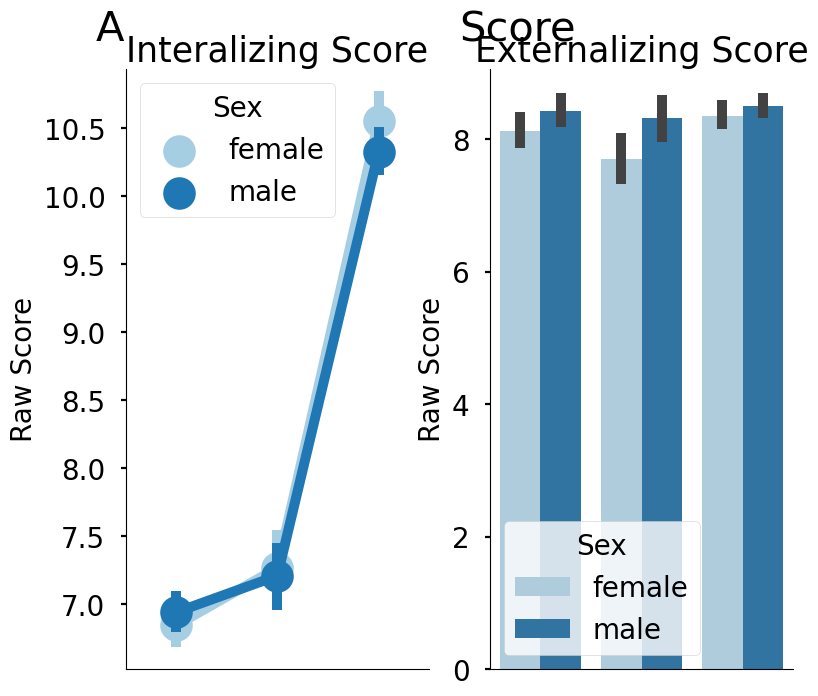

In [40]:
vis.plotting_style()
x_pos = -0.1
y_pos = 1.1
labelsize = 30
plt.clf()
fig = plt.figure(figsize=(1,))
gs = GridSpec(1, 2, figure=fig)

# A
ax = fig.add_subplot(gs[0,0])
ax = sns.pointplot(x='assessment', 
            y='value', 
            hue='Sex', 
            data=df_reshaped[df_reshaped['Int_Ext']=='Int'], 
            ax=ax
            )
plt.ylabel('Raw Score')
plt.xlabel('')
ax.xaxis.set_visible(False)
plt.title('Interalizing Score')
ax.text(x_pos, y_pos, 'A', transform=ax.transAxes, fontsize=labelsize, verticalalignment='top')

# B
ax = fig.add_subplot(gs[0,1])
ax = sns.pointplot(x='assessment', 
            y='value', 
            hue='Sex', 
            data=df_reshaped[df_reshaped['Int_Ext']=='Ext'], 
            ax=ax
            )
plt.ylabel('Raw Score')
plt.xlabel('')
ax.xaxis.set_visible(False)
plt.title('Externalizing Score')
ax.text(x_pos, y_pos, 'Score', transform=ax.transAxes, fontsize=labelsize, verticalalignment='top')
sns.despine()

fig.subplots_adjust(left=0.125, bottom=0.001, right=6.8, top=3.0, wspace=.2, hspace=.3)

fig.savefig(os.path.join(Defaults.FIG_DIR, f'raw-scores-int-ext-male-female.png'), bbox_inches='tight')
